In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lqg import xcorr

from cppp.load import preprocess_multisensory_data, load_multisensory_data

df = load_multisensory_data(base_path="../data")
df.head()


Multisensory DataFrame loaded from ../data/multisensory/df_downsampled.csv with shape: (15701, 9)


,session,participant,trial_number,type,vis_noise,time,lefty_pos,righty_pos,cursory_pos
0,2,135033060,7,vis,1,8.338,19.896919,17.680711,17.788407
1,2,135033060,7,vis,1,8.413,18.744622,17.681910,18.777561
2,2,135033060,7,vis,1,8.488,17.607245,17.680198,21.530017
3,2,135033060,7,vis,1,8.563,16.523169,17.680769,21.386902
4,2,135033060,7,vis,1,8.638,15.932538,17.680512,20.837665


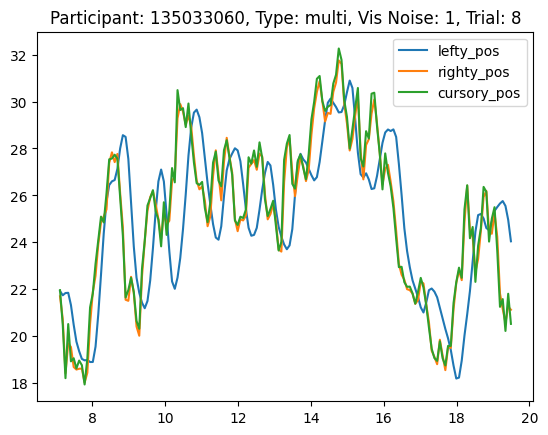

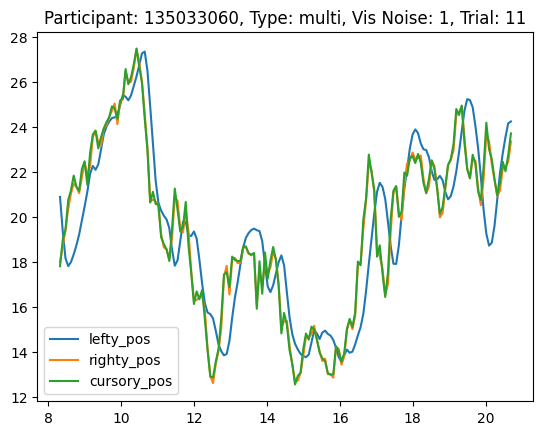

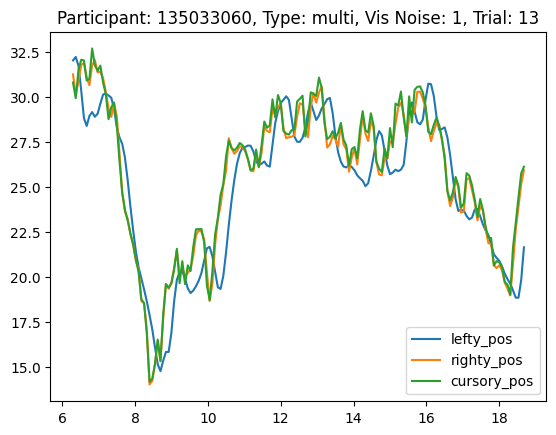

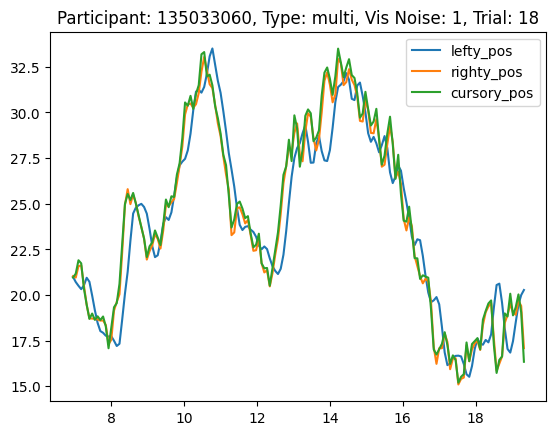

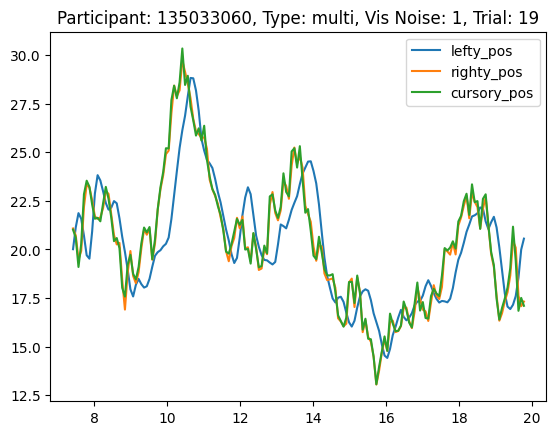

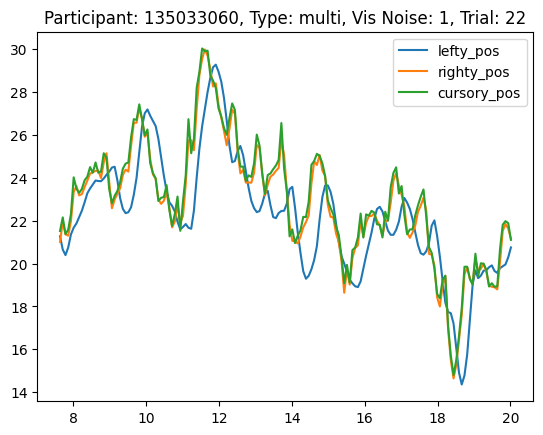

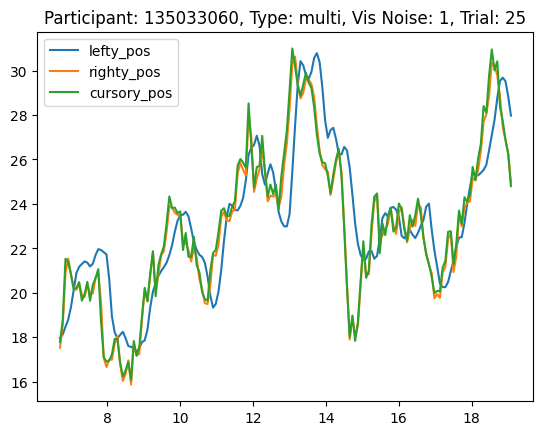

In [2]:
for i, (name, group) in enumerate(df.groupby(["participant", "type", "vis_noise", "trial_number"])):
    plt.plot(group["time"], group["lefty_pos"], label="lefty_pos")
    plt.plot(group["time"], group["righty_pos"], label="righty_pos")
    plt.plot(group["time"], group["cursory_pos"], label="cursory_pos")
    plt.title(f"Participant: {name[0]}, Type: {name[1]}, Vis Noise: {name[2]}, Trial: {name[3]}")
    plt.legend()
    plt.show()

    if i > 5:
        break

(6, 166, 2)
0.010738785481807758
(7, 165, 2)
0.010206144488136894
(9, 166, 2)
0.010263462771953861
(9, 166, 2)
0.010667161095618057
(8, 166, 2)
0.010435591623506997
(8, 166, 2)
0.010274540851204468


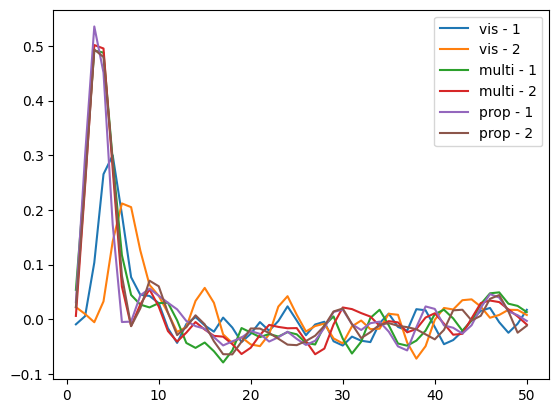

In [3]:


for condition in df["type"].unique():
    for vis_noise in df["vis_noise"].unique():
        data = preprocess_multisensory_data(df, participant=212056115, condition=condition, vis_noise=vis_noise)
        print(data.shape)
        print(np.diff(data[..., 0], axis=-1).std() / 100)

        vels = np.diff(data, axis=1)
        lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

        plt.plot(lags[51:], correls.mean(axis=0)[51:], label=f"{condition} - {vis_noise}")
plt.legend()



In [ ]:
import arviz as az

from jax import random

from cppp.models.multisensory import MultisensoryDelayModel, UnisensoryDelayModel


{'action_cost': 0.027, 'action_variability': 0.23, 'sigmas': [4.876, 5.552]}


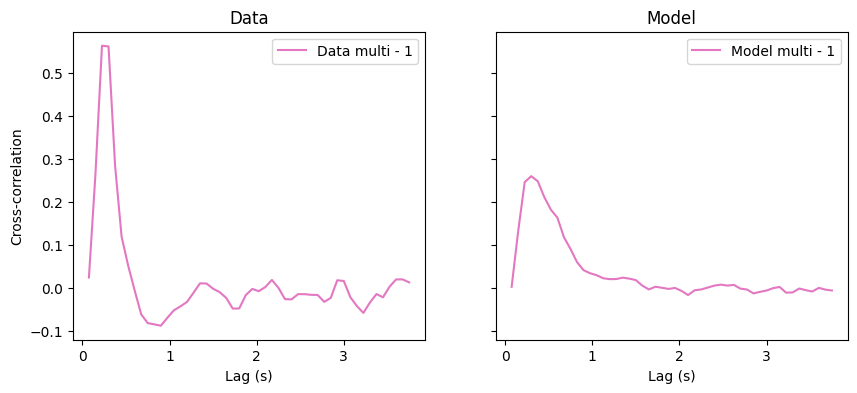

In [16]:

delays = {"vis": 2, "prop": 1}

f, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition = "multi"
vis_noise = 1
inference_data = az.from_netcdf(
            f"../results/multisensory-mcmc-{condition}-{vis_noise}-1.nc"
        )
summary = az.summary(inference_data)

posterior_mean = summary["mean"].to_dict()
posterior_mean["sigmas"] = [posterior_mean.pop("sigmas[0]"), posterior_mean.pop("sigmas[1]")]
print(posterior_mean)


model = MultisensoryDelayModel(**posterior_mean, T=data.shape[1], delays=[delays["prop"], delays["vis"]],  dt=0.075, process_noise=1.2)
sim_data = model.simulate(
    rng_key=random.PRNGKey(0), n=100
)

sim_vels = np.diff(sim_data, axis=1)
lags, sim_correls = xcorr(sim_vels[:, :, 1], sim_vels[:, :, 0], maxlags=50)

data = preprocess_multisensory_data(df, participant=135033060, condition=condition, vis_noise=vis_noise)
vels = np.diff(data, axis=1)
lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

ax[0].plot(lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"Data {condition} - {vis_noise}", linestyle="-" if vis_noise == 1 else "--", color=f"C{i}")
ax[1].plot(lags[51:] * 0.075, sim_correls.mean(axis=0)[51:], label=f"Model {condition} - {vis_noise}", linestyle="-" if vis_noise == 1 else "--", color=f"C{i}")

# multisensory prediction


ax[0].set_xlabel("Lag (s)")
ax[1].set_xlabel("Lag (s)")
ax[0].set_ylabel("Cross-correlation")
ax[0].set_title("Data")
ax[1].set_title("Model")
ax[0].legend()
ax[1].legend()

{'action_cost': 0.027, 'action_variability': 0.23, 'sigmas[0]': 4.876, 'sigmas[1]': 5.552}
{'action_cost': 0.026, 'action_variability': 0.282, 'sigma': 5.081}
{'action_cost': 0.034, 'action_variability': 0.103, 'sigma': 3.427}


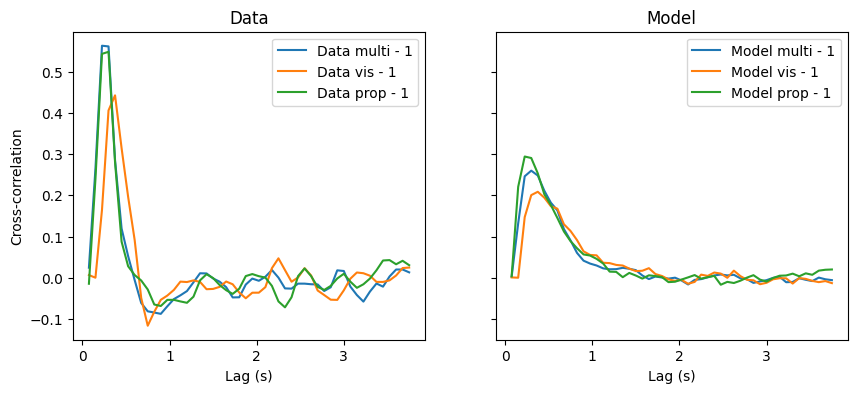

In [20]:
delays = {"vis": 2, "prop": 1}

f, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i, condition in enumerate(["multi", "vis", "prop"]):
    for vis_noise in [1]:
        inference_data = az.from_netcdf(
            f"../results/multisensory-mcmc-{condition}-{vis_noise}-1.nc"
        )
        summary = az.summary(inference_data)

        posterior_mean = summary["mean"].to_dict()
        print(posterior_mean)

        if condition == "multi":
            posterior_mean["sigmas"] = [posterior_mean.pop("sigmas[0]"), posterior_mean.pop("sigmas[1]")]
            model = MultisensoryDelayModel(**posterior_mean, T=data.shape[1], delays=[delays["prop"], delays["vis"]], dt=0.075, process_noise=1.2)
        else:
            model = UnisensoryDelayModel(**posterior_mean, T=data.shape[1], delay=delays[condition], dt=0.075, process_noise=1.2)
        sim_data = model.simulate(
            rng_key=random.PRNGKey(0), n=100
        )

        sim_vels = np.diff(sim_data, axis=1)
        lags, sim_correls = xcorr(sim_vels[:, :, 1], sim_vels[:, :, 0], maxlags=50)

        data = preprocess_multisensory_data(df, participant=135033060, condition=condition, vis_noise=vis_noise)
        vels = np.diff(data, axis=1)
        lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

        ax[0].plot(lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"Data {condition} - {vis_noise}", linestyle="-" if vis_noise == 1 else "--", color=f"C{i}")
        ax[1].plot(lags[51:] * 0.075, sim_correls.mean(axis=0)[51:], label=f"Model {condition} - {vis_noise}", linestyle="-" if vis_noise == 1 else "--", color=f"C{i}")

# multisensory prediction


ax[0].set_xlabel("Lag (s)")
ax[1].set_xlabel("Lag (s)")
ax[0].set_ylabel("Cross-correlation")
ax[0].set_title("Data")
ax[1].set_title("Model")
ax[0].legend()
ax[1].legend()